# Model Training Steps

## Hyper-Parmeters And Imports

In [ ]:
import os
import time
try:
    import h5py
except Exception:
    h5py = None
    print("h5py not installed; data-loading cells that require .h5 files will fail until installed.")
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import DataLoader, TensorDataset
try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    SummaryWriter = None
    print("tensorboard not installed; logging to TensorBoard disabled.")
from datetime import timedelta
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix

In [2]:

DATA_PATH = './data/SVHN_unified_norm_gray.h5'
SVHN_VERSION = 'svhn_v16_pytorch'
CHECKPOINT_PATH = os.path.join('checkpoints', SVHN_VERSION)
LOG_DIR = os.path.join('logs', SVHN_VERSION)

os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)


BATCH_SIZE = 512
EPOCHS = 20
LEARNING_RATE = 1e-3
DECAY_STEPS = 8800
DECAY_GAMMA = 0.5
DISPLAY_STEP = 100

FILTER_SIZES = [5, 5, 5, 5, 5, 5, 5]
NUM_FILTERS = [32, 48, 64, 80, 96, 112, 128]
FC1_SIZE = 1024
FC2_SIZE = 1024
NUM_LABELS = 11 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Utils functions

* **`init_weights`**: Initializes the neural network weights using "Xavier" or "He" initialization methods. This helps the model converge faster during training.

In [3]:
def init_weights(layer, method='xavier'):
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        if method == 'he':
            init.kaiming_uniform_(layer.weight, nonlinearity='leaky_relu', a=0.10)
        else:
            init.xavier_uniform_(layer.weight)
        if layer.bias is not None:
            init.constant_(layer.bias, 0.0)


* **`calculate_loss`**: Since we have 5 outputs, the total loss is the **sum** of the Cross Entropy Loss for each of the 5 digits.

In [4]:
def calculate_loss(outputs, labels, criterion):
    y1, y2, y3, y4, y5 = outputs
    # Labels shape: [batch, 5]
    loss = criterion(y1, labels[:, 0]) + \
           criterion(y2, labels[:, 1]) + \
           criterion(y3, labels[:, 2]) + \
           criterion(y4, labels[:, 3]) + \
           criterion(y5, labels[:, 4])
    return loss


* **`calculate_accuracy`**: A stricter accuracy metric. It considers a prediction correct only if **all 5 digits** in the sequence match the label perfectly.

In [5]:
def calculate_accuracy(outputs, labels):
    stacked_logits = torch.stack(outputs, dim=1) # [Batch, 5, Num_Classes]
    predictions = torch.argmax(stacked_logits, dim=2) # [Batch, 5]
    
    # Check if WHOLE sequence matches
    correct_sequences = (predictions == labels).all(dim=1).float()
    return correct_sequences.mean().item() * 100.0


In [6]:
def evaluate(model, loader, device):
    model.eval()
    total_acc = 0
    count = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_acc += calculate_accuracy(outputs, labels) * images.size(0) # weighted average
            count += images.size(0)
    return total_acc / count


* **`load_checkpoint`**: Checks if a previous training session exists. If yes, it loads the weights so you can continue training instead of starting from scratch.

In [7]:
def load_checkpoint(model, optimizer, checkpoint_dir):
    try:
        files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]
        if not files:
            print("No checkpoint found. Starting from scratch.")
            return 0
        latest_file = max(files, key=os.path.getctime)
        print(f"Restoring from: {latest_file}")
        checkpoint = torch.load(latest_file, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return checkpoint['epoch']
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return 0


## Layers and Model

* **`ConvLayer`**: A custom block containing a Convolution -> Batch Normalization -> Leaky ReLU activation -> and optional Average Pooling.


* **`FCLayer`**: A Fully Connected (Linear) layer, optionally followed by Leaky ReLU activation.

In [8]:
class ConvLayer(nn.Module):
    def __init__(self, in_channels, num_filters, filter_size, pooling=False, initializer='xavier'):
        super(ConvLayer, self).__init__()
        # Padding calculation to mimic TF 'SAME' with stride 1
        padding = (filter_size - 1) // 2
        
        self.conv = nn.Conv2d(in_channels, num_filters, kernel_size=filter_size, stride=1, padding=padding)
        self.bn = nn.BatchNorm2d(num_filters)
        self.activation = nn.LeakyReLU(negative_slope=0.10)
        self.pooling = pooling
        
        if self.pooling:
            self.pool_layer = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
            
        init_weights(self.conv, method=initializer)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        if self.pooling:
            x = self.pool_layer(x)
        return x


In [9]:
class FCLayer(nn.Module):
    def __init__(self, input_dim, output_dim, relu=False, initializer='xavier'):
        super(FCLayer, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.use_relu = relu
        if self.use_relu:
            self.activation = nn.LeakyReLU(negative_slope=0.10)
        init_weights(self.fc, method=initializer)

    def forward(self, x):
        x = self.fc(x)
        if self.use_relu:
            x = self.activation(x)
        return x


* **3 Convolutional Blocks**: Each block extracts features from the image using the custom `ConvLayer`. We use **Dropout** between blocks to prevent overfitting.
* **Flattening**: Converts the 3D feature maps into a 1D vector so it can be fed into the fully connected layers.
* **Shared Fully Connected Layers**: `fc1` and `fc2` process the features extracted by the CNN.
* **5 Parallel Output Heads** (`digit1` to `digit5`): Since SVHN images contain sequences (e.g., "123"), the model has 5 separate output layers. Each layer predicts one digit in the sequence.

In [10]:
class SVHNModel(nn.Module):
    def __init__(self, num_channels=1):
        super(SVHNModel, self).__init__()
        
        # Block 1
        self.conv1 = ConvLayer(num_channels, NUM_FILTERS[0], FILTER_SIZES[0], pooling=False)
        self.conv2 = ConvLayer(NUM_FILTERS[0], NUM_FILTERS[1], FILTER_SIZES[1], pooling=True)
        self.drop1 = nn.Dropout(p=0.1) # p=dropout_rate (1 - keep_prob)

        # Block 2
        self.conv3 = ConvLayer(NUM_FILTERS[1], NUM_FILTERS[2], FILTER_SIZES[2], pooling=False)
        self.conv4 = ConvLayer(NUM_FILTERS[2], NUM_FILTERS[3], FILTER_SIZES[3], pooling=True)
        self.drop2 = nn.Dropout(p=0.1)

        # Block 3
        self.conv5 = ConvLayer(NUM_FILTERS[3], NUM_FILTERS[4], FILTER_SIZES[4], pooling=False)
        self.conv6 = ConvLayer(NUM_FILTERS[4], NUM_FILTERS[5], FILTER_SIZES[5], pooling=False)
        self.conv7 = ConvLayer(NUM_FILTERS[5], NUM_FILTERS[6], FILTER_SIZES[6], pooling=True)
        self.drop3 = nn.Dropout(p=0.5)

        # Flatten calc: 32x32 -> (pool) -> 16x16 -> (pool) -> 8x8 -> (pool) -> 4x4
        self.flat_features = 4 * 4 * NUM_FILTERS[6]
        
        # Fully Connected
        self.fc1 = FCLayer(self.flat_features, FC1_SIZE, relu=True)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = FCLayer(FC1_SIZE, FC2_SIZE, relu=True)

        # Output Heads (5 digits)
        self.digit1 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit2 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit3 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit4 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)
        self.digit5 = FCLayer(FC2_SIZE, NUM_LABELS, relu=False)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.drop1(x)
        # Block 2
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.drop2(x)
        # Block 3
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.drop3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC
        x = self.fc1(x)
        x = self.drop_fc(x)
        x = self.fc2(x)
        
        return self.digit1(x), self.digit2(x), self.digit3(x), self.digit4(x), self.digit5(x)


## Load data


* **Crucial Step**: It performs a **Transpose** operation `(0, 3, 1, 2)`.
* The H5 file (from the original script) stores images as `(Batch, Height, Width, Channels)`.

In [11]:
def load_data(h5_path):
    if not os.path.exists(h5_path):
        raise FileNotFoundError(f"File {h5_path} not found!")
        
    print("Loading H5 data...")
    with h5py.File(h5_path, 'r') as h5f:
        X_train = h5f['X_train'][:]
        y_train = h5f['y_train'][:]
        X_val = h5f['X_val'][:]
        y_val = h5f['y_val'][:]
        X_test = h5f['X_test'][:]
        y_test = h5f['y_test'][:]

    # PyTorch expects (N, Channels, Height, Width)
    # H5 (from script) is (N, Height, Width, Channels)
    # We transpose: (0, 3, 1, 2)
    X_train = np.transpose(X_train, (0, 3, 1, 2))
    X_val = np.transpose(X_val, (0, 3, 1, 2))
    X_test = np.transpose(X_test, (0, 3, 1, 2))
    
    print(f"Train shape: {X_train.shape}")
    print(f"Val shape: {X_val.shape}")
    print(f"Test shape: {X_test.shape}")
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


## Training

This function manages the entire lifecycle:

1. Loads the data and wraps it in PyTorch `DataLoader` (handles shuffling and batching).
2. Initializes the Model, Optimizer (Adam), and Scheduler (StepLR).
3. **The Loop**: Iterates through `EPOCHS`. inside:
* **Forward Pass**: Passes images through the model.
* **Loss Calculation**: Computes the error.
* **Backward Pass**: Updates weights using backpropagation.
* **Logging**: Prints progress and saves logs for TensorBoard.


4. **Validation**: Evaluates the model on unseen data at the end of every epoch.
5. **Saving**: Saves the model to a `.pth` file.

In [ ]:
def train_process():
# 1. Load Data
(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(DATA_PATH)

# Create DataLoaders
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
val_ds = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
test_ds = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# 2. Init Model
model = SVHNModel(num_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=DECAY_STEPS, gamma=DECAY_GAMMA)
criterion = nn.CrossEntropyLoss()
writer = SummaryWriter(LOG_DIR)

# 3. Restore Checkpoint
start_epoch = load_checkpoint(model, optimizer, CHECKPOINT_PATH)
global_step = start_epoch * len(train_loader)

print("Starting training...")
start_time_total = time.time()

for epoch in range(start_epoch, EPOCHS):
    print('='*30)
    print(f'Epoch {epoch+1}/{EPOCHS}')
    print('='*30)
    
    model.train()
    epoch_start = time.time()
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = calculate_loss(outputs, labels, criterion)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        global_step += 1
        
        if i % DISPLAY_STEP == 0:
            acc = calculate_accuracy(outputs, labels)
            print(f"Step {i}: Loss: {loss.item():.4f}, Train Acc: {acc:.2f}%")
            writer.add_scalar('Loss/train', loss.item(), global_step)
            writer.add_scalar('Accuracy/train', acc, global_step)

    # Validation
    val_acc = evaluate(model, val_loader, device)
    print(f"Validation Accuracy: {val_acc:.2f}%")
    writer.add_scalar('Accuracy/validation', val_acc, epoch)
    
    print(f"Epoch Time: {str(timedelta(seconds=int(time.time()-epoch_start)))}")
    
    # Save Checkpoint
    save_path = os.path.join(CHECKPOINT_PATH, f'{SVHN_VERSION}_epoch_{epoch+1}.pth')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, save_path)
    print("Model saved.")

print("Training Complete.")
print(f"Total Time: {str(timedelta(seconds=int(time.time()-start_time_total)))}")

# Final Test
test_acc = evaluate(model, test_loader, device)
print(f"Final Test Accuracy: {test_acc:.2f}%")
writer.close()
return model


In [ ]:
if "train_process" not in globals():
    print("train_process not initialized (training cell was skipped).")
else:
    model = train_process()


# Model Evaluation

## Utils Functions

In [14]:
def labels_to_string(label_tensor):
    """
    ממיר טנסור של תוויות (למשל [1, 2, 10, 10, 10]) למחרוזת קריאה ("12").
    הנחה: 10 מייצג 'אין ספרה' או ריפוד.
    """
    label_str = ""
    for digit in label_tensor:
        d = int(digit.item())
        if d != 10:  # נניח ש-10 זה הריפוד
            label_str += str(d)
    return label_str if label_str else "0" # במקרה נדיר של רצף ריק


In [15]:
def denormalize_image(image_tensor):
    """
    מחזיר את התמונה לטווח 0-1 לצורך תצוגה (אם בוצע נרמול Z-score).
    אם הנרמול היה פשוט, נצטרך להתאים את זה. כאן נניח מינימום/מקסימום להצגה.
    """
    img = image_tensor.numpy().transpose(1, 2, 0) # (C, H, W) -> (H, W, C)
    # נרמול פשוט להצגה (Min-Max)
    img = (img - img.min()) / (img.max() - img.min())
    return img


In [16]:
def plot_images_grid(images, true_labels, pred_labels, title, num_rows=3, num_cols=4):
    """
    מציג גריד של תמונות עם התחזית והאמת.
    """
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 2.5 * num_rows))
    fig.suptitle(title, fontsize=16)
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i >= len(images):
            break
        
        img = denormalize_image(images[i])
        ax.imshow(img.squeeze(), cmap='gray') # squeeze למקרה שזה גווני אפור
        
        true_str = labels_to_string(true_labels[i])
        pred_str = labels_to_string(pred_labels[i])
        
        # צבע כותרת: ירוק אם צדק, אדום אם טעה
        color = 'green' if true_str == pred_str else 'red'
        
        ax.set_title(f"True: {true_str}\nPred: {pred_str}", color=color, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


## Main Eval Function

In [17]:
def evaluate_and_visualize(model_path, data_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating using device: {device}")

    # 1. טעינת הדאטה
    (_, _), (_, _), (X_test, y_test) = load_data(data_path)
    
    # יצירת DataLoader לטסט
    test_ds = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False) # לא מערבבים כדי לשמור על סדר לאנליזה

    # 2. טעינת המודל
    model = SVHNModel(num_channels=1).to(device)
    
    # טעינת המשקולות (נטען את האחרון שנשמר או ספציפי)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("Model loaded successfully.")

    # 3. ביצוע תחזיות על כל ה-Test Set
    all_preds = []
    all_labels = []
    all_images = []
    
    print("Running predictions on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images) # (y1, y2, y3, y4, y5)
            
            # המרת פלט לחיזוי סופי
            stacked_logits = torch.stack(outputs, dim=1) # [Batch, 5, 11]
            predictions = torch.argmax(stacked_logits, dim=2) # [Batch, 5]
            
            all_preds.append(predictions.cpu())
            all_labels.append(labels)
            all_images.append(images.cpu())

    # איחוד כל הבאצ'ים
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_images = torch.cat(all_images)

    # ==========================================
    # 3. חישוב מדדים (Metrics)
    # ==========================================
    
    # בדיקה האם כל הרצף נכון
    correct_mask = (all_preds == all_labels).all(dim=1)
    sequence_accuracy = correct_mask.float().mean().item() * 100
    
    print("-" * 40)
    print(f"Final Sequence Accuracy: {sequence_accuracy:.2f}%")
    print("-" * 40)

    # דיוק לפי מיקום הספרה
    print("Accuracy by digit position:")
    for i in range(5):
        pos_acc = (all_preds[:, i] == all_labels[:, i]).float().mean().item() * 100
        print(f"  Digit {i+1}: {pos_acc:.2f}%")
    print("-" * 40)

    # ==========================================
    # 4. ויזואליזציה (כמו במחברת)
    # ==========================================

    # א. הצגת דוגמאות אקראיות (גם טובות וגם רעות)
    print("\nVisualizing Random Predictions:")
    indices = np.random.choice(len(all_images), 12, replace=False)
    plot_images_grid(all_images[indices], all_labels[indices], all_preds[indices], "Random Test Examples")

    # ב. הצגת דוגמאות שגויות בלבד (Error Analysis)
    incorrect_indices = torch.where(~correct_mask)[0]
    
    if len(incorrect_indices) > 0:
        print(f"\nFound {len(incorrect_indices)} misclassified examples.")
        # נציג 12 טעויות אקראיות
        show_n_errors = min(12, len(incorrect_indices))
        error_indices = np.random.choice(incorrect_indices.numpy(), show_n_errors, replace=False)
        
        plot_images_grid(
            all_images[error_indices], 
            all_labels[error_indices], 
            all_preds[error_indices], 
            "Misclassified Examples (Errors)",
            num_rows=3, num_cols=4
        )
    else:
        print("\nAmazing! 100% Accuracy. No errors to show.")

    return sequence_accuracy


Evaluating using device: cuda
Loading H5 data...
Train shape: (243679, 1, 32, 32)
Val shape: (27076, 1, 32, 32)
Test shape: (14374, 1, 32, 32)
Model loaded successfully.
Running predictions on test set...
----------------------------------------
Final Sequence Accuracy: 92.97%
----------------------------------------
Accuracy by digit position:
  Digit 1: 96.55%
  Digit 2: 96.22%
  Digit 3: 98.21%
  Digit 4: 99.74%
  Digit 5: 99.99%
----------------------------------------

Visualizing Random Predictions:


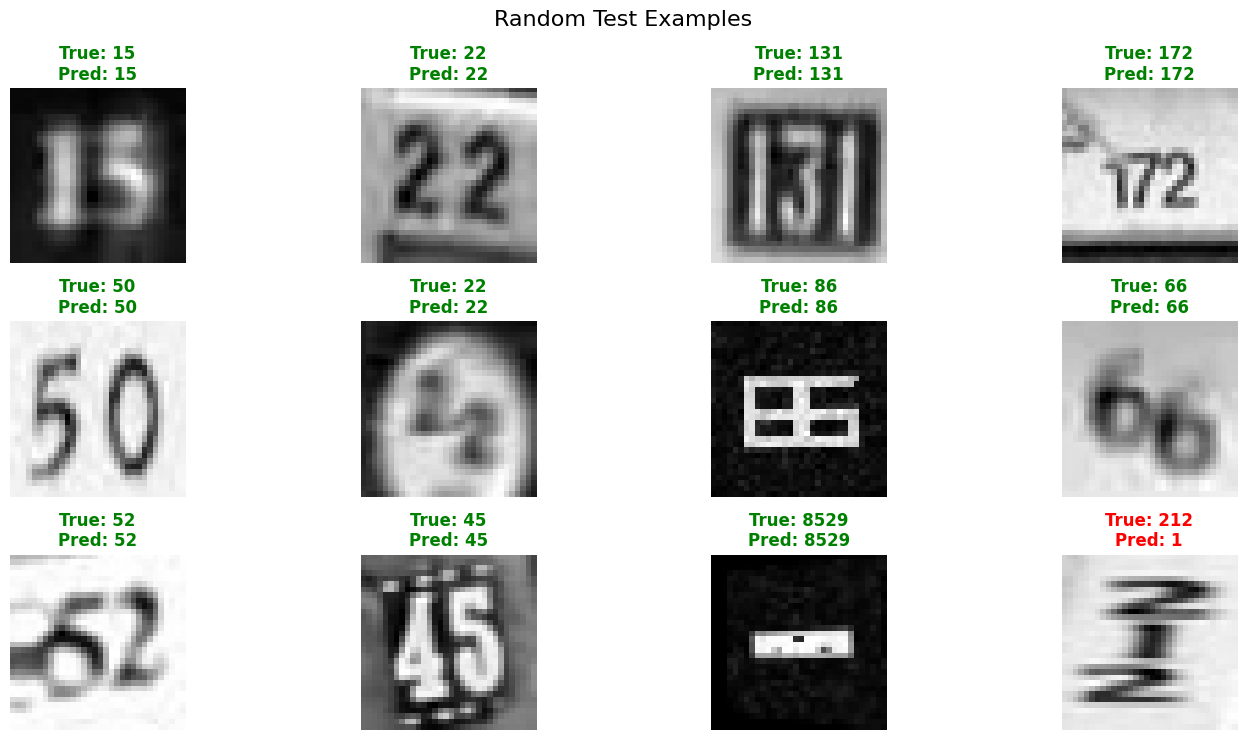


Found 1010 misclassified examples.


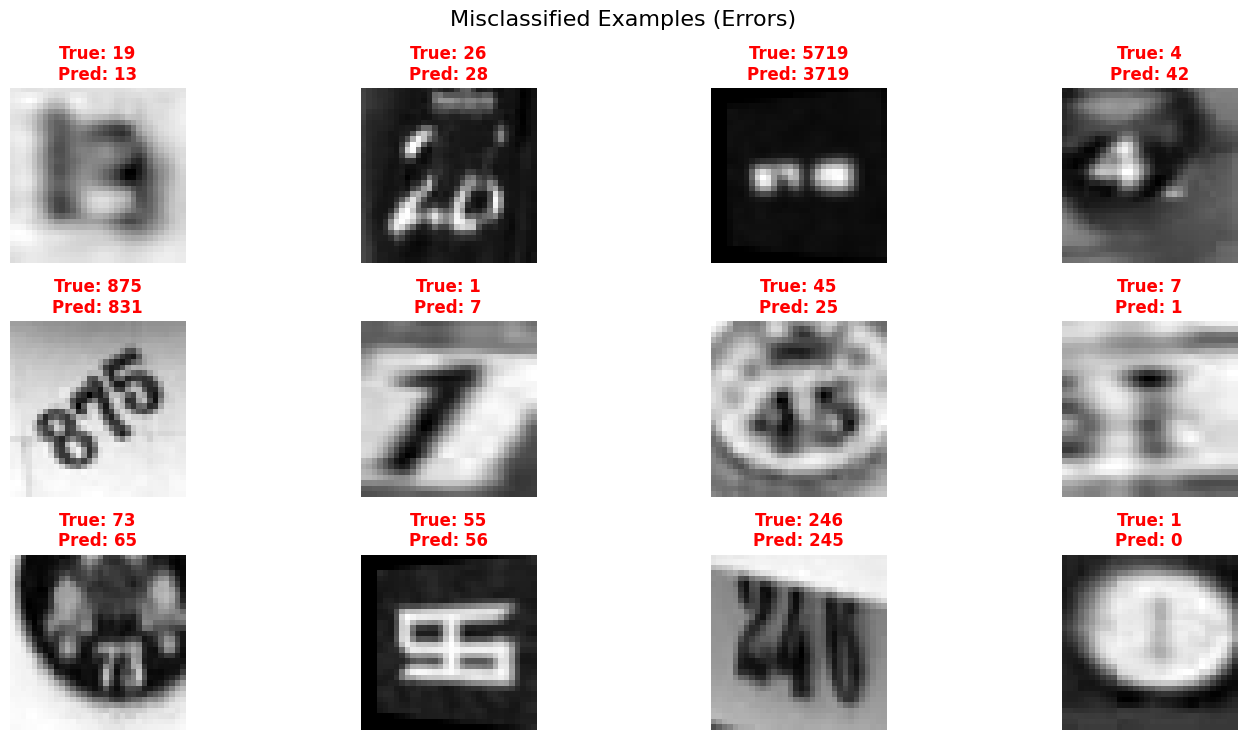

In [ ]:
checkpoint_dir = os.path.join('checkpoints', 'svhn_v16_pytorch')
try:
    files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]
    latest_model = max(files, key=os.path.getctime)
    
    evaluate_and_visualize('./svhn-cnn-model.pth', DATA_PATH)

except Exception as e:
    print(f"Could not run evaluation: {e}")
    print("Make sure you ran the training script first and generated checkpoints.")

Evaluating using device: cuda
Loading H5 data...
Train shape: (243679, 1, 32, 32)
Val shape: (27076, 1, 32, 32)
Test shape: (14374, 1, 32, 32)
Model loaded successfully.
Running predictions on test set...
----------------------------------------
Final Sequence Accuracy: 92.97%
----------------------------------------
Accuracy by digit position:
  Digit 1: 96.55%
  Digit 2: 96.22%
  Digit 3: 98.21%
  Digit 4: 99.74%
  Digit 5: 99.99%
----------------------------------------

Visualizing Random Predictions:


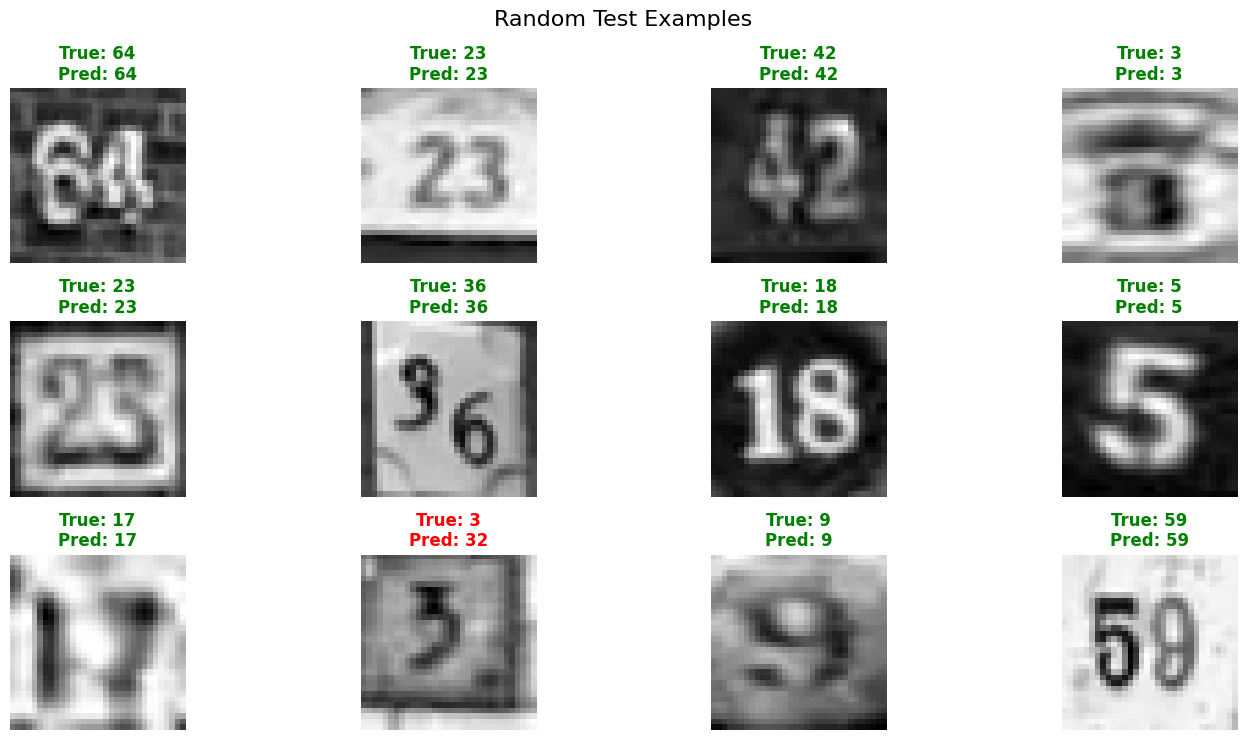


Found 1010 misclassified examples.


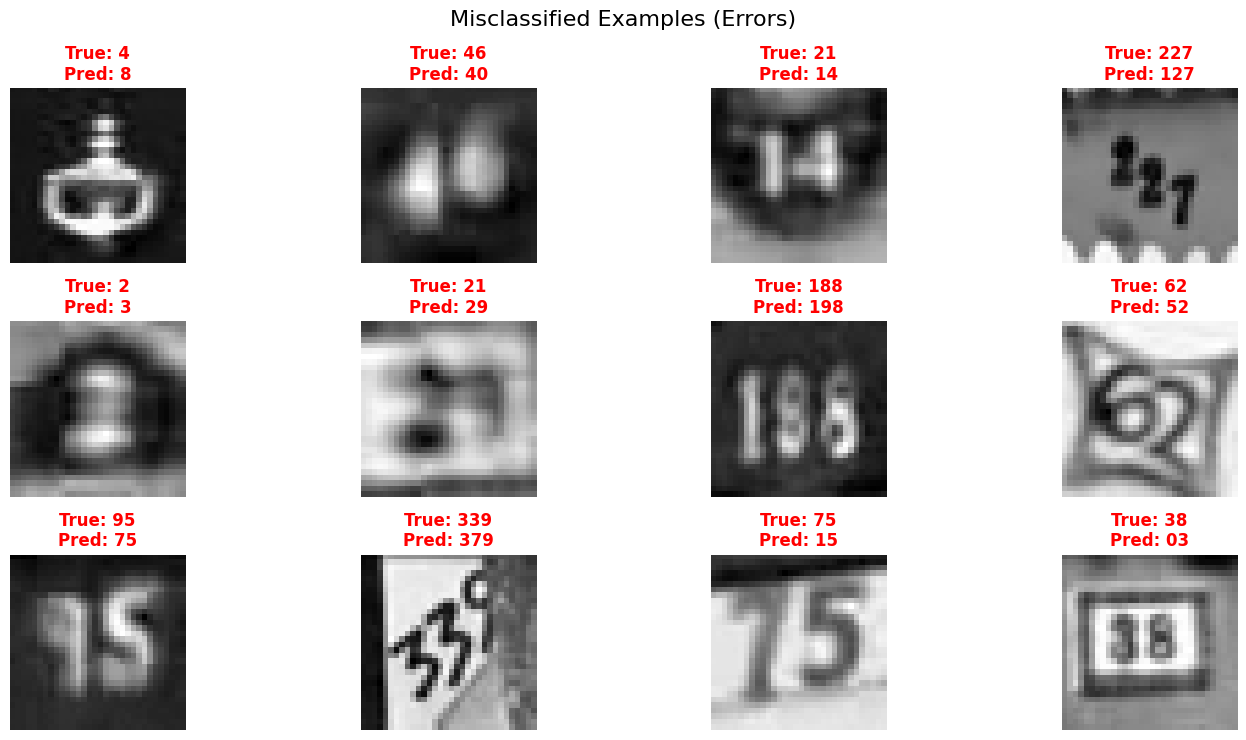

In [ ]:
checkpoint_dir = os.path.join('checkpoints', 'svhn_v16_pytorch')
try:
    files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]
    latest_model = max(files, key=os.path.getctime)
    
    evaluate_and_visualize(latest_model, DATA_PATH)

except Exception as e:
    print(f"Could not run evaluation: {e}")
    print("Make sure you ran the training script first and generated checkpoints.")